#### The problem

The main question is: can we predict if a customer has churned their subscription using the available data?

The dataset contains customer data with the following features:
- plan_type (basic, plus, or premium)
- tenure_months (how long the subscription has been active)
- sessions_last_30d (user engagement in the last 30 days)
- monthly_price
- support_tickets_last_90d (number of support tickets in the last 90 days, indicating friction)
- auto_renew (whether the subscription auto-renews)
- churned (1 if the customer churned, 0 if still active)

The column "churned" is the target to predict.

In [83]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
from collections import Counter
import csv
import statistics as stats
import seaborn as sns
import numpy as np

DATA_PATH = Path("data/capstone_customers.csv")
customers_data = pd.read_csv(DATA_PATH)

customers_data.head()

,customer_id,country,plan_type,tenure_months,sessions_last_30d,avg_session_minutes,support_tickets_last_90d,monthly_price,auto_renew,churned
0,1001,DE,basic,3,4,18.5,0,19,1,1
1,1002,DE,plus,8,9,26.2,1,29,1,0
2,1003,US,basic,1,2,12.4,0,19,0,1
3,1004,US,premium,14,16,34.1,2,49,1,0
4,1005,GB,plus,6,7,22.0,1,29,1,0


In [84]:
print(f"The dataset has {customers_data.shape[0]} rows and {customers_data.shape[1]} columns")
customers_data.info()

The dataset has 20 rows and 10 columns
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               20 non-null     int64  
 1   country                   20 non-null     str    
 2   plan_type                 20 non-null     str    
 3   tenure_months             20 non-null     int64  
 4   sessions_last_30d         20 non-null     int64  
 5   avg_session_minutes       20 non-null     float64
 6   support_tickets_last_90d  20 non-null     int64  
 7   monthly_price             20 non-null     int64  
 8   auto_renew                20 non-null     int64  
 9   churned                   20 non-null     int64  
dtypes: float64(1), int64(7), str(2)
memory usage: 1.7 KB


### A brief summary helps detect errors in the dataset and provides a clear overview of categorical columns

In [85]:
def read_rows(path):
    with open(path, 'r', encoding='utf-8') as reader:
        return list(csv.DictReader(reader))

def summary_categorical(rows):
    counts = Counter()
    for row in rows:
        for key, value in row.items():
            try:
                float(value)
                continue
            except (ValueError, TypeError):
                pass
            counts[str(value).strip()] += 1
    return dict(counts)

def summary_numerical(rows):
    columns = {}
    for row in rows:
        for key, value in row.items():
            if key == "customer_id":
                continue
            try:
                number = float(value)
            except (ValueError, TypeError):
                continue
            columns.setdefault(key, []).append(number)

    resume = {}
    for key, values in columns.items():
        min_value = min(values)
        max_value = max(values)
        resume[key] = {
            "min": min_value,
            "max": max_value,
            "range": max_value - min_value,
            "std": stats.pstdev(values) if len(values) > 1 else 0.0,
        }
    return resume


In [86]:
raw_rows = read_rows(DATA_PATH)
print(f'Raw rows: {len(raw_rows)}')

resume = summary_categorical(customers_data.to_dict(orient="records"))

for key, value in resume.items():
    print(f"{key}, {value}")

Raw rows: 20
DE, 5
basic, 8
plus, 7
US, 6
premium, 5
GB, 5
FR, 4


In [87]:
resume_num = summary_numerical(raw_rows)
for key, value in resume_num.items():
    print(f"{key}: {value}")

tenure_months: {'min': 1.0, 'max': 20.0, 'range': 19.0, 'std': 5.584576975922169}
sessions_last_30d: {'min': 1.0, 'max': 21.0, 'range': 20.0, 'std': 5.998958242895178}
avg_session_minutes: {'min': 9.6, 'max': 38.7, 'range': 29.1, 'std': 8.479202497876791}
support_tickets_last_90d: {'min': 0.0, 'max': 3.0, 'range': 3.0, 'std': 0.9096702699330126}
monthly_price: {'min': 19.0, 'max': 49.0, 'range': 30.0, 'std': 11.789826122551595}
auto_renew: {'min': 0.0, 'max': 1.0, 'range': 1.0, 'std': 0.4330127018922193}
churned: {'min': 0.0, 'max': 1.0, 'range': 1.0, 'std': 0.458257569495584}


#### Exploratory analysis

- With the basic checks complete, we can begin exploring the data. 
- We start by examining the balance of the churned class to determine whether the target variable is balanced. 
This will affect how we interpret accuracy, precision, and recall in later analyses.

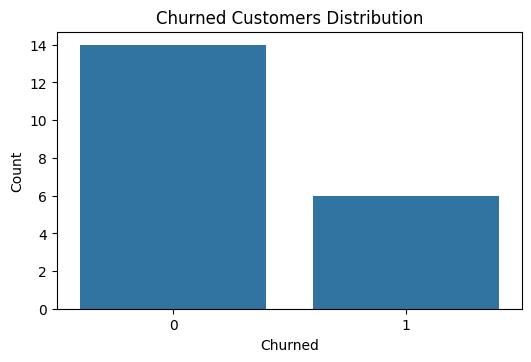

In [88]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
sns.countplot(x="churned", data=customers_data, ax=ax)
ax.set_title("Churned Customers Distribution")
ax.set_xlabel("Churned")
ax.set_ylabel("Count")
plt.show()


Another interesting question is whether there is any relationship between `support_tickets_last_90d` and churn.

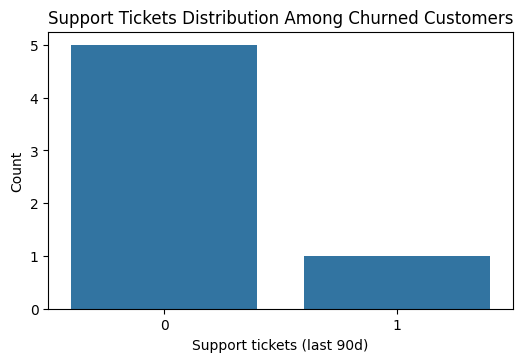

customer_id 1010


In [89]:
churned_customers = customers_data[customers_data["churned"] == 1]

fig, ax = plt.subplots(figsize=(6.0, 3.6))
sns.countplot(x="support_tickets_last_90d", data=churned_customers, ax=ax)
ax.set_title("Support Tickets Distribution Among Churned Customers")
ax.set_xlabel("Support tickets (last 90d)")
ax.set_ylabel("Count")
plt.show()

for idx, row in churned_customers.iterrows():
    if row["support_tickets_last_90d"] > 0:
        print(f"customer_id {row['customer_id']}")
   


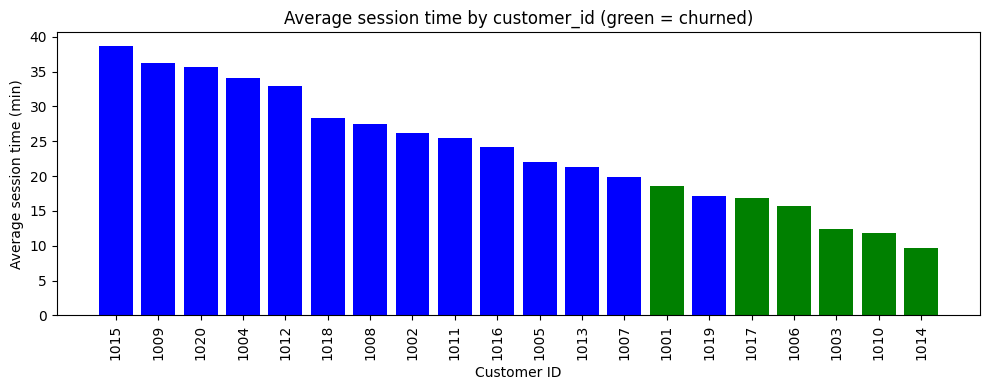

In [90]:
sorted_data = customers_data.sort_values(by="avg_session_minutes", ascending=False)

plt.figure(figsize=(10, 4))

bar_colors = ['green' if churned == 1 else 'blue' for churned in sorted_data['churned']]

plt.bar(
    sorted_data["customer_id"].astype(str),
    sorted_data["avg_session_minutes"],
    color=bar_colors
)
plt.title("Average session time by customer_id (green = churned)")
plt.xlabel("Customer ID")
plt.ylabel("Average session time (min)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

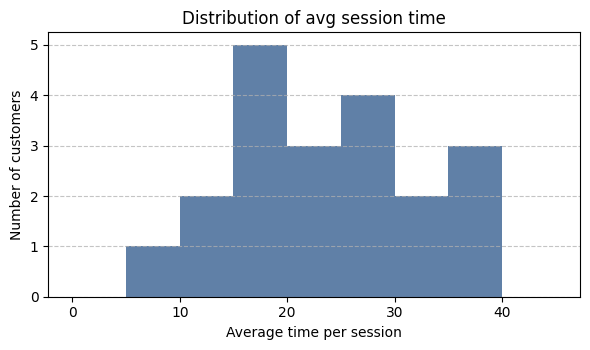

In [102]:

avg_session = customers_data["avg_session_minutes"].sort_values().to_list()

fig, ax = plt.subplots(figsize=(6.0, 3.6))

ax.hist(avg_session, bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45], color="#0B3C78", alpha=0.65)
ax.set_title("Distribution of avg session time")
ax.set_xlabel("Average time per session")
ax.set_ylabel("Number of customers")

ax.grid(
    axis="y",
    alpha=0.75,
    linestyle="--",
    linewidth=0.8,
)

fig.tight_layout()
plt.show()

Comparing key numeric features by `churned` makes short tenure and low engagement visible: churned customers tend to have shorter tenure and fewer/shorter sessions, not extreme high engagement.

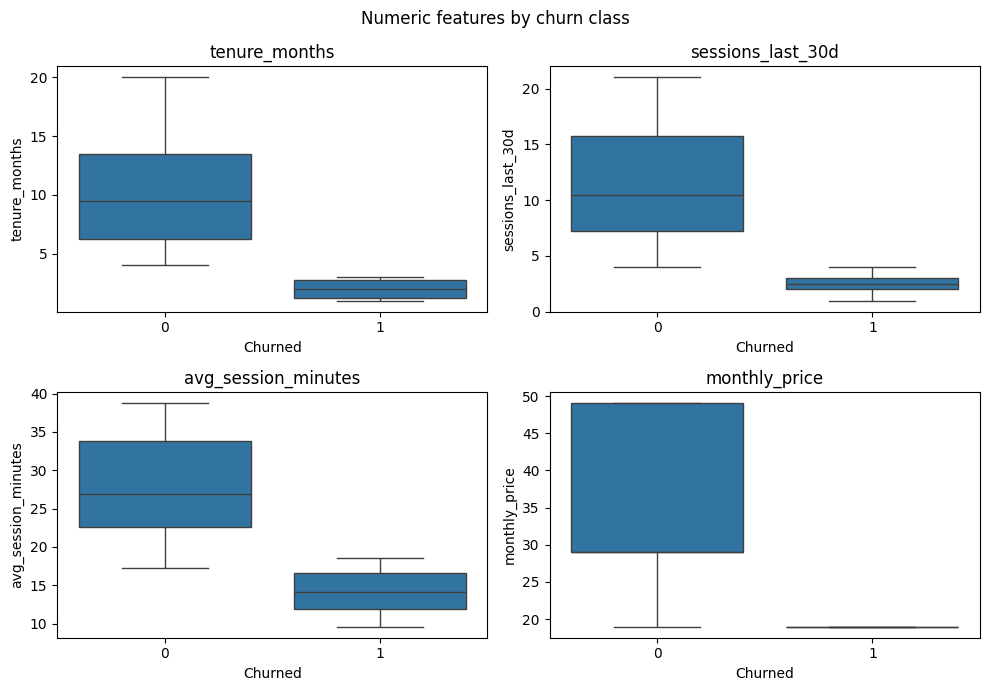

         tenure_months  sessions_last_30d  avg_session_minutes  monthly_price
churned                                                                      
0                10.21              11.43                27.84          34.71
1                 2.00               2.50                14.13          19.00


In [103]:
features = [
    "tenure_months",
    "sessions_last_30d",
    "avg_session_minutes",
    "monthly_price",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feature in zip(axes.flat, features):
    sns.boxplot(x="churned", y=feature, data=customers_data, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Churned")
    ax.set_ylabel(feature)

fig.suptitle("Numeric features by churn class")
fig.tight_layout()
plt.show()

print(customers_data.groupby("churned")[features].mean().round(2))

Categorical features vs `churned` (counts and row %). Churn concentrates on `plan_type=basic` and `auto_renew=0`.

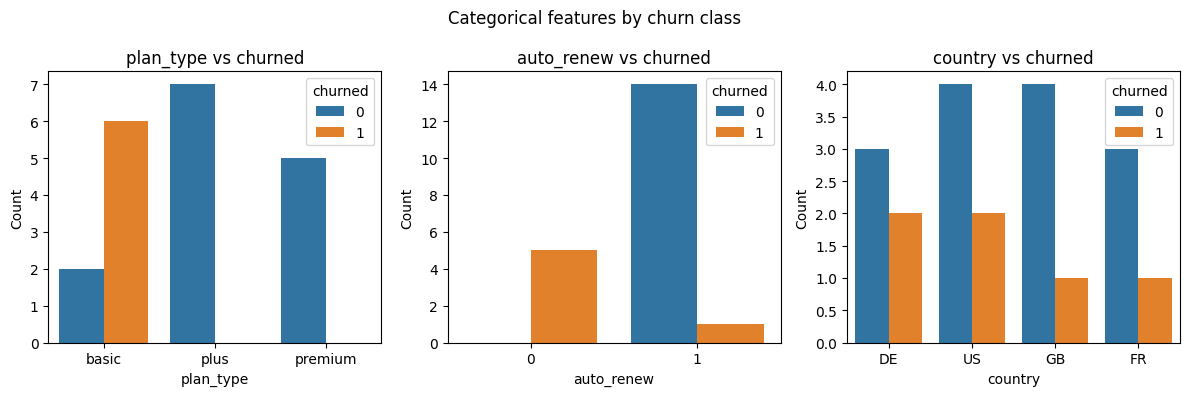

In [111]:
categorical_features = ["plan_type", "auto_renew", "country"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, feature in zip(axes, categorical_features):
    sns.countplot(x=feature, hue="churned", data=customers_data, ax=ax)
    ax.set_title(f"{feature} vs churned")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

fig.suptitle("Categorical features by churn class")
fig.tight_layout()
plt.show()


Scatter of `tenure_months` × `sessions_last_30d` colored by `churned`. Clear separation into two groups supports tree-based models (Decision Tree / Random Forest).

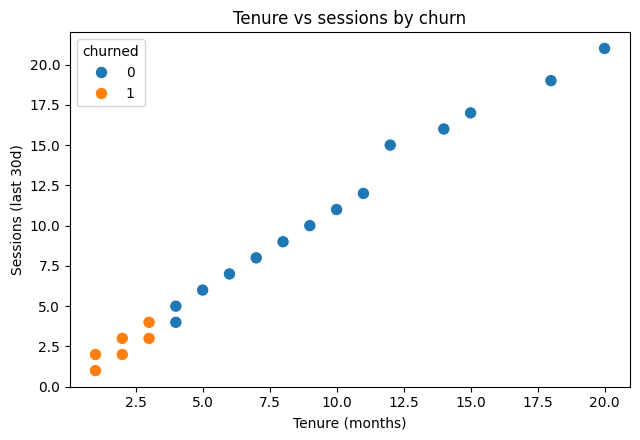

In [112]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.scatterplot(
    data=customers_data,
    x="tenure_months",
    y="sessions_last_30d",
    hue="churned",
    ax=ax,
    s=80,
)
ax.set_title("Tenure vs sessions by churn")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Sessions (last 30d)")
fig.tight_layout()
plt.show()

#### Exploratory conclusions and model suggestions

**Dataset context.** The analysis uses 20 customers and 10 columns, with no missing values in `customers_data.info()`. The target `churned` is imbalanced: the class-balance countplot shows more active customers (`churned=0`) than churned ones (`churned=1`). Accuracy alone will therefore overstate a model that mostly predicts “active”.

**Main quirks from the plots and summaries.**

1. **Short tenure and low engagement, not high engagement.** The boxplots and group means show a large gap by class:
   - active: mean tenure **10.21**, sessions **11.43**, avg session minutes **27.84**, monthly price **34.71**
   - churned: mean tenure **2.00**, sessions **2.50**, avg session minutes **14.13**, monthly price **19.00**  
   Churned customers sit on the low end of tenure and engagement. The bar chart of `avg_session_minutes` (green = churned) and the session histogram are consistent with that: longer sessions belong mostly to active customers.

2. **Support tickets are a weak churn signal here.** Among churned customers, the tickets countplot is dominated by **0** tickets; only `customer_id` **1010** has tickets &gt; 0. Friction via tickets does not look like the main pattern in this sample.

3. **Categorical concentration.** The countplots of `plan_type`, `auto_renew`, and `country` vs `churned` show churn concentrated in **`plan_type=basic`** and **`auto_renew=0`**. Plus/premium and `auto_renew=1` are mostly active. `country` differences look milder than plan and auto-renew.

4. **Two groups in feature space.** The scatter of `tenure_months` × `sessions_last_30d` colored by `churned` separates churned customers toward short tenure and few sessions, while active customers sit toward longer tenure and higher session counts. That split is useful for tree-based rules.

**Model suggestions grounded in this EDA.**

- Prefer features that actually separated classes in the analysis: `tenure_months`, `sessions_last_30d`, `avg_session_minutes`, `monthly_price`, `plan_type`, and `auto_renew`. Treat `support_tickets_last_90d` and `country` as secondary until modeling confirms value.
- **Decision Tree / Random Forest** fit the observed separation and the basic / no-auto-renew concentration (simple threshold and interaction rules). With only 20 rows, keep trees shallow / regularized to limit overfitting.
- **Logistic Regression** is still reasonable: the numeric means differ strongly and in a fairly consistent direction by class, so a linear decision boundary can work after encoding `plan_type` (and possibly `country`).
- Evaluate with **precision and recall** (and compare all three models), not accuracy alone, because of the class imbalance seen in the churn countplot.

Overall, the exploratory analysis points to churn as “new, low-engagement, basic / non-auto-renew” customers rather than “high-engagement or high-ticket” customers in this dataset.